### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [2]:
df = pd.read_csv('fraudTest.csv')

In [3]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

## Create Function to calculate distgance from latitude and long titude

In [7]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the Earth's surface using Haversine formula.
    """
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [8]:
# Calculate distances and create new column
df['distance_km'] = haversine(df['merch_long'], df['merch_lat'], df['long'], df['lat'])

In [9]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance_km
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,24.561462
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,104.925092
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,59.080078
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,27.698567
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,104.335106


In [10]:
df= df.drop(['Unnamed: 0','first','last','merch_lat','merch_long','lat','long','street'], axis=1)

In [11]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,dob,trans_num,unix_time,is_fraud,distance_km
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,0,24.561462
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,0,104.925092
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,0,59.080078
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,0,27.698567
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,0,104.335106


## Creating age column

In [12]:
from datetime import datetime

# Convert 'dob' column to datetime format
df.loc[:, 'dob'] = pd.to_datetime(df['dob'])

# Calculate age based on current date
current_date = datetime.now()
df.loc[:, 'age'] = (current_date - df['dob']).astype('<m8[Y]')  # Calculate age in years

# Display the updated dataframe with 'age' column
df.head()

C:\Users\Daisy\AppData\Local\Temp\ipykernel_7204\2372286152.py:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.loc[:, 'dob'] = pd.to_datetime(df['dob'])


,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,dob,trans_num,unix_time,is_fraud,distance_km,age
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,0,24.561462,56.0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,0,104.925092,34.0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,0,59.080078,53.0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,0,27.698567,36.0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,0,104.335106,69.0


In [13]:
df= df.drop(['dob'], axis=1)

In [14]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,trans_num,unix_time,is_fraud,distance_km,age
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,0,24.561462,56.0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,0,104.925092,34.0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,0,59.080078,53.0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,0,27.698567,36.0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,0,104.335106,69.0


## Create month,day_of_week, hour columns form trans_date_trans_time	

In [17]:
# Convert 'trans_date_trans_time' column to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract components
df['month'] = df['trans_date_trans_time'].dt.month
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['hour'] = df['trans_date_trans_time'].dt.hour

In [18]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,trans_num,unix_time,is_fraud,distance_km,age,month,day_of_week,hour
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,0,24.561462,56.0,6,6,12
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,0,104.925092,34.0,6,6,12
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,0,59.080078,53.0,6,6,12
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,0,27.698567,36.0,6,6,12
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,0,104.335106,69.0,6,6,12


In [19]:
df= df.drop(['trans_date_trans_time'], axis=1)

In [20]:
df.head()

,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,trans_num,unix_time,is_fraud,distance_km,age,month,day_of_week,hour
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,0,24.561462,56.0,6,6,12
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,0,104.925092,34.0,6,6,12
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,0,59.080078,53.0,6,6,12
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,0,27.698567,36.0,6,6,12
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,0,104.335106,69.0,6,6,12


## Split X,y to do Feature Engineering

In [22]:
from sklearn.model_selection import train_test_split
# split data into 80/20 
X = df.drop('is_fraud', axis = 1)
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 12, stratify = y)

# specifically hard copying the training sets to avoid Pandas' SetttingWithCopyWarning when we play around with this data later on.
X_train, X_test = X_train.copy(), X_test.copy()

In [23]:
X.head()

,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,trans_num,unix_time,distance_km,age,month,day_of_week,hour
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,24.561462,56.0,6,6,12
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,104.925092,34.0,6,6,12
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,59.080078,53.0,6,6,12
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,27.698567,36.0,6,6,12
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,104.335106,69.0,6,6,12


In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cc_num       555719 non-null  int64  
 1   merchant     555719 non-null  object 
 2   category     555719 non-null  object 
 3   amt          555719 non-null  float64
 4   gender       555719 non-null  object 
 5   city         555719 non-null  object 
 6   state        555719 non-null  object 
 7   zip          555719 non-null  int64  
 8   city_pop     555719 non-null  int64  
 9   job          555719 non-null  object 
 10  trans_num    555719 non-null  object 
 11  unix_time    555719 non-null  int64  
 12  distance_km  555719 non-null  float64
 13  age          555719 non-null  float64
 14  month        555719 non-null  int64  
 15  day_of_week  555719 non-null  int64  
 16  hour         555719 non-null  int64  
dtypes: float64(3), int64(7), object(7)
memory usage: 72.1+ MB


## Divide training data into categorical and numerical subsets

In [25]:
X_train_cat = X_train.select_dtypes(include ='object').copy()
X_train_num = X_train.select_dtypes(include = 'number' ).copy()

In [26]:
X_train_cat.head()

,merchant,category,gender,city,state,job,trans_num
447265,"fraud_Kilback, Nitzsche and Leffler",travel,F,Clarks Mills,PA,Energy manager,31893c8a2ece13cfd7698f8b5092a9f5
41021,fraud_Graham and Sons,health_fitness,F,Chatham,NY,Human resources officer,2aea8a621851721de762054148bd2d27
492956,"fraud_Turcotte, McKenzie and Koss",entertainment,M,Ozawkie,KS,Theatre director,f87a6eeac0ed610cb15425eafeb43bae
281268,fraud_Erdman-Ebert,personal_care,F,Avoca,IA,Engineering geologist,1c90179bfc1b7fe9aff989b783be70a9
207528,fraud_White and Sons,home,F,Lawn,PA,Special educational needs teacher,5d150161cf40f20d7d13c2a5da535aba


In [27]:
X_train_cat.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 444575 entries, 447265 to 450260
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   merchant   444575 non-null  object
 1   category   444575 non-null  object
 2   gender     444575 non-null  object
 3   city       444575 non-null  object
 4   state      444575 non-null  object
 5   job        444575 non-null  object
 6   trans_num  444575 non-null  object
dtypes: object(7)
memory usage: 27.1+ MB


In [28]:
X_train_num.head()

,cc_num,amt,zip,city_pop,unix_time,distance_km,age,month,day_of_week,hour
447265,6538441737335434,3.22,16114,606,1386452638,81.012576,26.0,12,0,21
41021,30011465039817,86.13,12037,4015,1373047773,114.681539,52.0,7,6,18
492956,4060579726528237,144.36,66070,2661,1387342291,69.963520,75.0,12,4,4
281268,4198470814557,52.20,51521,2036,1380900248,68.856007,52.0,10,6,15
207528,4169759661243568,30.14,17041,213,1378061834,76.983284,52.0,9,1,18


In [29]:
X_train_num.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 444575 entries, 447265 to 450260
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cc_num       444575 non-null  int64  
 1   amt          444575 non-null  float64
 2   zip          444575 non-null  int64  
 3   city_pop     444575 non-null  int64  
 4   unix_time    444575 non-null  int64  
 5   distance_km  444575 non-null  float64
 6   age          444575 non-null  float64
 7   month        444575 non-null  int64  
 8   day_of_week  444575 non-null  int64  
 9   hour         444575 non-null  int64  
dtypes: float64(3), int64(7)
memory usage: 37.3 MB


## Feature selection using chi2 for categorical columns

In [30]:
from scipy.stats import chi2_contingency

# define an empty dictionary to store chi-squared test results
chi2_check = {}

# loop over each column in the training set to calculate chi-statistic with the target variable
for column in X_train_cat:
    chi, p, dof, ex = chi2_contingency(pd.crosstab(y_train, X_train_cat[column]))
    chi2_check.setdefault('Feature',[]).append(column)
    chi2_check.setdefault('p-value',[]) .append(round(p, 10))

# convert the dictionary to a DF
chi2_result = pd.DataFrame(data = chi2_check)
chi2_result.sort_values(by =['p-value'], ascending = True, ignore_index = True, inplace = True)
print(chi2_result)

     Feature   p-value
0   merchant  0.000000
1   category  0.000000
2       city  0.000000
3      state  0.000000
4        job  0.000000
5  trans_num  0.499295
6     gender  1.000000


## Interpretation:
### Low p-values (close to 0):

Features: merchant, category, city, state, job
Interpretation: These features have very low p-values, indicating that there is a statistically significant association between these features and the target variable. In other words, changes in these features are highly likely to be associated with changes in the target variable.
### Higher p-values (close to 1):

Features: trans_num, gender
Interpretation: These features have higher p-values, suggesting that there is no statistically significant association between these features and the target variable. This means changes in these features are not likely to be associated with changes in the target variable.

## Feature selection using ANOVA for numerical columns

In [31]:
from sklearn.feature_selection import f_classif
# since f_class_if does not accept missing values, we will do a very crude imputation of missing values
X_train_num.fillna(X_train_num.mean(), inplace = True)
# Calculate F Statistic and corresponding p values
F_statistic, p_values = f_classif(X_train_num, y_train)
# convert to a DF
ANOVA_F_table = pd.DataFrame(data = {'Numerical_Feature': X_train_num.columns.values, 'F-Score': F_statistic, 'p values': p_values.round(decimals=10)})
ANOVA_F_table.sort_values(by = ['F-Score' ], ascending = False, ignore_index = True, inplace = True)
ANOVA_F_table.head(10)

,Numerical_Feature,F-Score,p values
0,amt,14935.869207,0.000000e+00
1,hour,75.418682,0.000000e+00
2,unix_time,67.325361,0.000000e+00
3,month,53.796818,0.000000e+00
4,day_of_week,40.714355,2.000000e-10
5,age,25.441530,4.562000e-07
6,city_pop,11.423372,7.253218e-04
7,cc_num,3.577879,5.855451e-02
8,zip,2.284737,1.306530e-01
9,distance_km,0.007920,9.290874e-01


## Interpretation:
### Significant Features:

Features with lower p-values (e.g., amt, hour, unix_time, month, day_of_week,age, city_pop) are considered statistically significant. Their F-Scores indicate that these features explain a significant amount of variance in the target variable.

### Less Significant Features:
Features with higher p-values (e.g., cc_num, zip,distance_km) are considered less statistically significant. Their F-Scores are lower, indicating they explain less variance in the target variable compared to other features.

might keep cc_num since it is borderline significant

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cc_num       555719 non-null  int64  
 1   merchant     555719 non-null  object 
 2   category     555719 non-null  object 
 3   amt          555719 non-null  float64
 4   gender       555719 non-null  object 
 5   city         555719 non-null  object 
 6   state        555719 non-null  object 
 7   zip          555719 non-null  int64  
 8   city_pop     555719 non-null  int64  
 9   job          555719 non-null  object 
 10  trans_num    555719 non-null  object 
 11  unix_time    555719 non-null  int64  
 12  is_fraud     555719 non-null  int64  
 13  distance_km  555719 non-null  float64
 14  age          555719 non-null  float64
 15  month        555719 non-null  int64  
 16  day_of_week  555719 non-null  int64  
 17  hour         555719 non-null  int64  
dtypes: float64(3), int64(8),

In [32]:
df.head()

,cc_num,merchant,category,amt,gender,city,state,zip,city_pop,job,trans_num,unix_time,is_fraud,distance_km,age,month,day_of_week,hour
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,0,24.561462,56.0,6,6,12
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,1371816873,0,104.925092,34.0,6,6,12
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,1371816893,0,59.080078,53.0,6,6,12
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,1371816915,0,27.698567,36.0,6,6,12
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,1371816917,0,104.335106,69.0,6,6,12


                  amt      hour  unix_time     month  day_of_week       age  \
amt          1.000000 -0.029860  -0.000974 -0.000717     0.003414 -0.012826   
hour        -0.029860  1.000000  -0.000304 -0.004995     0.001516 -0.173866   
unix_time   -0.000974 -0.000304   1.000000  0.988955    -0.009987 -0.002657   
month       -0.000717 -0.004995   0.988955  1.000000    -0.004090 -0.001414   
day_of_week  0.003414  0.001516  -0.009987 -0.004090     1.000000  0.004318   
age         -0.012826 -0.173866  -0.002657 -0.001414     0.004318  1.000000   
city_pop     0.002760  0.018937  -0.000740 -0.001117    -0.002010 -0.092242   
cc_num       0.001963 -0.001137  -0.000810 -0.000542     0.003031 -0.001113   

             city_pop    cc_num  
amt          0.002760  0.001963  
hour         0.018937 -0.001137  
unix_time   -0.000740 -0.000810  
month       -0.001117 -0.000542  
day_of_week -0.002010  0.003031  
age         -0.092242 -0.001113  
city_pop     1.000000 -0.009414  
cc_num      -0.0

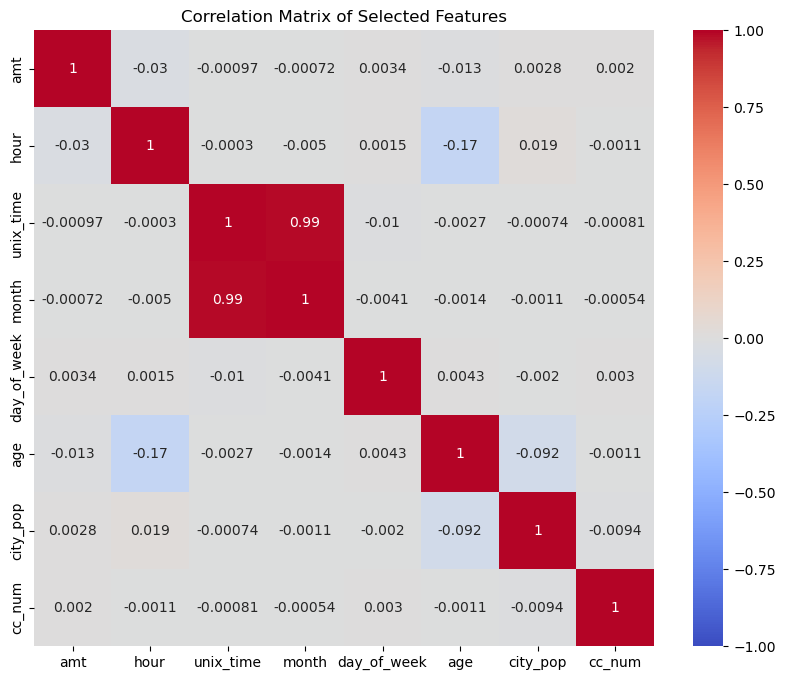

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the significant columns
selected_columns = ['amt', 'hour', 'unix_time', 'month', 'day_of_week', 'age', 'city_pop', 'cc_num']
df_selected = df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Print the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Selected Features')
plt.show()


## Key Observations
### amt (Amount):

Weakly correlated with all other features. The highest absolute correlation is with hour (-0.029860), which is very low.
Conclusion: Amount seems to be an independent feature.
hour:
Notable negative correlation with age (-0.173866).
Weak correlations with other features.
Conclusion: Transaction hour might have some relationship with age but is otherwise independent of other features.
### unix_time:
*Very high positive correlation with month (0.988955).
Very weak or near-zero correlation with other features.
*Conclusion: Since unix_time and month are highly correlated, you might consider using only one of them to avoid multicollinearity.
### month:

Very high positive correlation with unix_time (0.988955).
Very weak or near-zero correlation with other features.
Conclusion: Same as above, you might want to drop either unix_time or month.
day_of_week:

Very weak correlations with all features.
Conclusion: day_of_week appears to be independent of other features.
### age:

Notable negative correlation with hour (-0.173866).
Weak correlations with other features.
Conclusion: Age might have a moderate relationship with the transaction hour.
### city_pop (City Population):

Very weak correlations with all features.
Conclusion: city_pop appears to be an independent feature.
### cc_num (Credit Card Number):

Very weak correlations with all features.
Conclusion: cc_num appears to be an independent feature.
## Summary
Highly Correlated Features: unix_time and month are highly correlated. To avoid multicollinearity, you should consider dropping one of these features.
Moderately Correlated Features: hour and age show a moderate negative correlation, but this isn't necessarily a problem unless it significantly impacts your model's performance.
Independent Features: Most features have very weak correlations with each other, indicating that they are largely independent, which is beneficial for modeling as it reduces the risk of multicollinearity.

## Time to drop unncessary columns

In [35]:
df= df.drop(['trans_num','gender','unix_time','zip','distance_km'], axis=1)

In [36]:
df.head()

,cc_num,merchant,category,amt,city,state,city_pop,job,is_fraud,age,month,day_of_week,hour
0,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Columbia,SC,333497,Mechanical engineer,0,56.0,6,6,12
1,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Altonah,UT,302,"Sales professional, IT",0,34.0,6,6,12
2,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,34496,"Librarian, public",0,53.0,6,6,12
3,3591919803438423,fraud_Haley Group,misc_pos,60.05,Titusville,FL,54767,Set designer,0,36.0,6,6,12
4,3526826139003047,fraud_Johnston-Casper,travel,3.19,Falmouth,MI,1126,Furniture designer,0,69.0,6,6,12


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   cc_num       555719 non-null  int64  
 1   merchant     555719 non-null  object 
 2   category     555719 non-null  object 
 3   amt          555719 non-null  float64
 4   city         555719 non-null  object 
 5   state        555719 non-null  object 
 6   city_pop     555719 non-null  int64  
 7   job          555719 non-null  object 
 8   is_fraud     555719 non-null  int64  
 9   age          555719 non-null  float64
 10  month        555719 non-null  int64  
 11  day_of_week  555719 non-null  int64  
 12  hour         555719 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 55.1+ MB


## Handling Imbalanced data : Undersampling

Count each class

In [38]:
from sklearn.utils import resample

# Separate the majority and minority classes
df_majority = df[df.is_fraud == 0]
df_minority = df[df.is_fraud == 1]

# Print the number of instances in each class
print("Number of non-fraudulent transactions:", len(df_majority))
print("Number of fraudulent transactions:", len(df_minority))

Number of non-fraudulent transactions: 553574
Number of fraudulent transactions: 2145


Undersample the majority class

In [39]:
df_majority_undersampled = resample(df_majority, 
                                    replace=False,    # sample without replacement
                                    n_samples=len(df_minority),  # to match the minority class
                                    random_state=42)  # for reproducibility

Combine the undersampled majority class with the minority class

In [40]:
df_undersampled = pd.concat([df_majority_undersampled, df_minority])

In [41]:
df_undersampled.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4290 entries, 547885 to 517571
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cc_num       4290 non-null   int64  
 1   merchant     4290 non-null   object 
 2   category     4290 non-null   object 
 3   amt          4290 non-null   float64
 4   city         4290 non-null   object 
 5   state        4290 non-null   object 
 6   city_pop     4290 non-null   int64  
 7   job          4290 non-null   object 
 8   is_fraud     4290 non-null   int64  
 9   age          4290 non-null   float64
 10  month        4290 non-null   int64  
 11  day_of_week  4290 non-null   int64  
 12  hour         4290 non-null   int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 469.2+ KB


Shuffle the dataset to mix the rows

In [42]:
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

Print class distribution 

In [43]:
print("Number of non-fraudulent transactions after undersampling:", len(df_undersampled[df_undersampled.is_fraud == 0]))
print("Number of fraudulent transactions:", len(df_undersampled[df_undersampled.is_fraud == 1]))

Number of non-fraudulent transactions after undersampling: 2145
Number of fraudulent transactions: 2145


In [44]:
df_undersampled.head()

,cc_num,merchant,category,amt,city,state,city_pop,job,is_fraud,age,month,day_of_week,hour
0,5456712664803820,fraud_Kirlin and Sons,personal_care,51.86,Llano,NM,247,Architectural technologist,1,62.0,10,0,22
1,378858024506425,"fraud_Turner, Ziemann and Lehner",food_dining,77.57,Paradise Valley,AZ,17047,Building surveyor,0,89.0,10,6,6
2,3597926034019603,fraud_Pacocha-O'Reilly,grocery_pos,338.13,Oakland,TN,9496,Furniture conservator/restorer,1,31.0,9,1,3
3,30487648872433,fraud_Wolf Inc,grocery_pos,333.84,Central,IN,350,Counsellor,1,69.0,11,4,2
4,4883407061576,fraud_Kassulke PLC,shopping_net,974.36,Seattle,WA,837792,Systems developer,1,87.0,10,6,23


In [45]:
df_undersampled.nunique()

cc_num          795
merchant        678
category         14
amt            3865
city            739
state            49
city_pop        731
job             446
is_fraud          2
age              81
month             7
day_of_week       7
hour             24
dtype: int64

## Save as CSV file

In [46]:
# Save the undersampled dataframe to a CSV file
df_undersampled.to_csv('df_undersampled.csv', index=False)